## Ankita Ashok Deshmukh
### Class: MSCDS
### Roll No: DS24MS20
##  --------------------------------------------------

# Regression Project: Yulu Bike Sharing Demand Prediction

## Project Description:

### Business Context
In the evolving landscape of urban mobility, companies like Yulu Bike are at the forefront of
providing efficient and eco-friendly transportation solutions. Accurate prediction of bike-sharing
demand is crucial for optimizing fleet management, enhancing customer satisfaction, and
maximizing operational efficiency. By analyzing data related to bike-sharing demand, Yulu Bike
aims to gain a deeper understanding of the factors influencing bike rentals. The dataset includes
a range of variables such as weather conditions, time of day, and special events, which impact
bike usage patterns.

###### 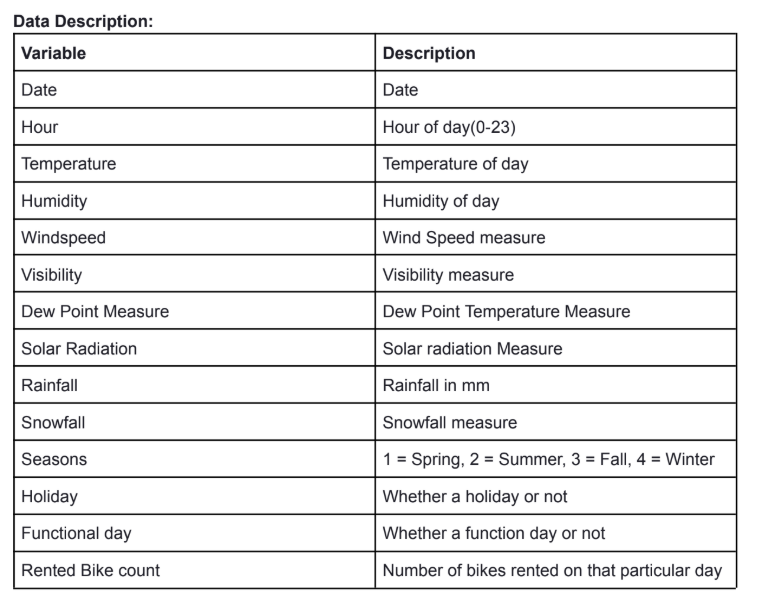

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
%matplotlib inline
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

## Loading data

In [6]:
df= pd.read_csv("https://raw.githubusercontent.com/rahulinchal/SPPU/refs/heads/main/Data/Car_Price_Prediction.csv")
#inspecting first five rows of dataset
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
#checking the number of rows and columns
df.shape

(4340, 8)

In [8]:
#getting some informaation about the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [9]:
#checking the number of missing values 
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,4340.0,2013.090783,4.215344,1992.0,2011.00,2014.0,2016.0,2020.0
selling_price,4340.0,504127.311751,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0
km_driven,4340.0,66215.777419,46644.102194,1.0,35000.00,60000.0,90000.0,806599.0


In [11]:
#checking the distribution of categorical data
print(df.fuel.value_counts())
print(df.seller_type.value_counts())
print(df.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


In [12]:
df['name'].unique()

array(['Maruti 800 AC', 'Maruti Wagon R LXI Minor',
       'Hyundai Verna 1.6 SX', ..., 'Mahindra Verito 1.5 D6 BSIII',
       'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
       'Hyundai i20 Magna 1.4 CRDi'], dtype=object)

- nothing can be dropped because everything is necessary in this dataset 

In [14]:
for i in df.select_dtypes('object').columns:
    print(i,"\n",df[i].unique(),"\n")

name 
 ['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi'] 

fuel 
 ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric'] 

seller_type 
 ['Individual' 'Dealer' 'Trustmark Dealer'] 

transmission 
 ['Manual' 'Automatic'] 

owner 
 ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car'] 



In [15]:
int_dtype=df.select_dtypes(include='int')

In [16]:
int_dtype.head()

,year,selling_price,km_driven
0,2007,60000,70000
1,2007,135000,50000
2,2012,600000,100000
3,2017,250000,46000
4,2014,450000,141000


In [17]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [18]:
df.nunique()

name             1491
year               27
selling_price     445
km_driven         770
fuel                5
seller_type         3
transmission        2
owner               5
dtype: int64

In [19]:
df.shape

(4340, 8)

In [20]:
df.shape

(4340, 8)

In [21]:
df.duplicated().sum()

763

In [22]:
#Remove duplicates
df.drop_duplicates(inplace=True)

## EXPLORATORY DATA ANALYSIS

In [24]:
#to extract only car brands without model and series we had created a new column and named it as car brand 
#split name with space delimeter

df['car_brand']=df['name'].str.split(' ')

df['car_brand'] = df['car_brand'].apply(lambda x: x[0])
df

df = df.drop(columns=['name'])
df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
...,...,...,...,...,...,...,...,...
4335,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4336,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4337,2009,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti
4338,2016,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai


In [25]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'car_brand'],
      dtype='object')

## UNIVARIATE ANALYSIS

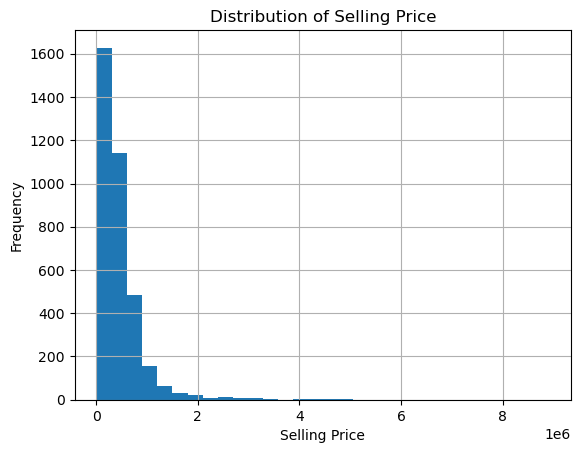

In [27]:
df['selling_price'].hist(bins=30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

-  to visualize the distribution of the "selling_price" column in a pandas DataFrame df using a histogram.


In [29]:
df['car_brand'].value_counts()

car_brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

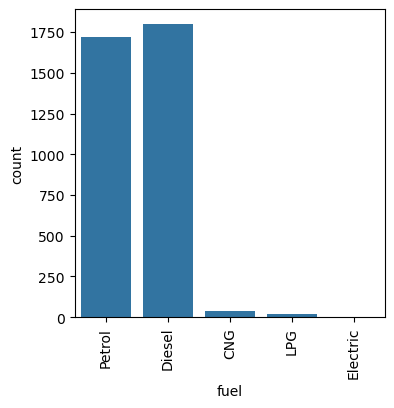

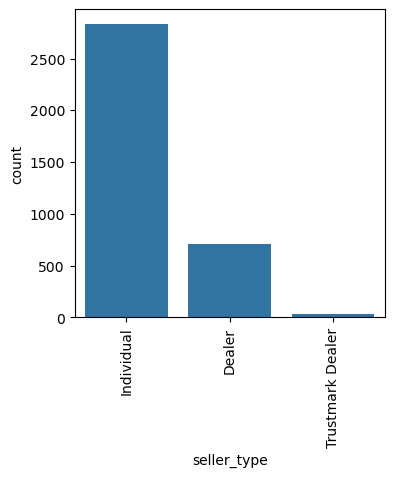

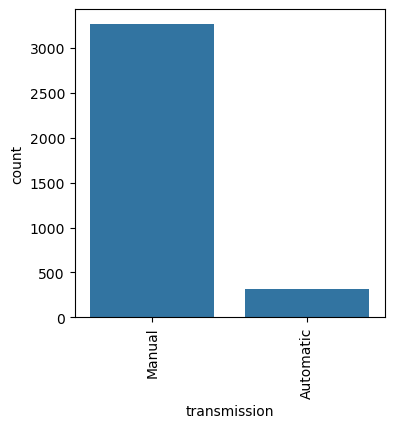

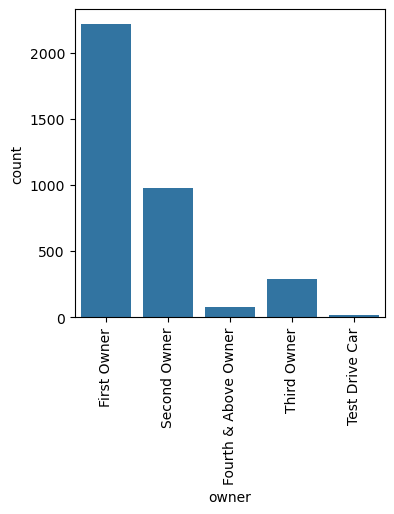

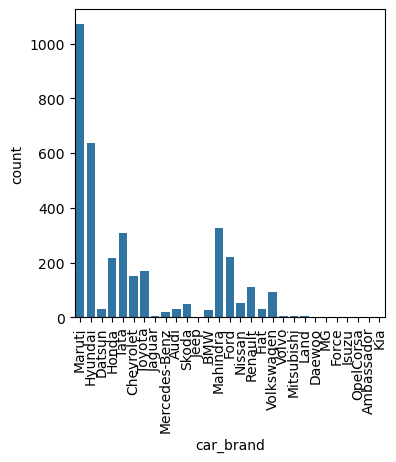

In [30]:
for i in df.select_dtypes('object').columns:
    plt.figure(figsize=(4,4))
    sns.countplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

- To generates count plots for each categorical column in the DataFrame df using seaborn's countplot function.

In [32]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


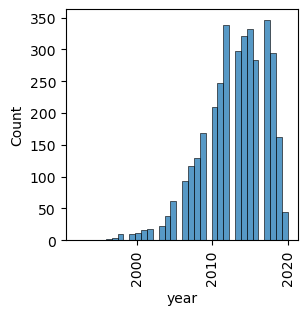

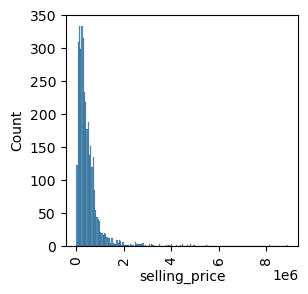

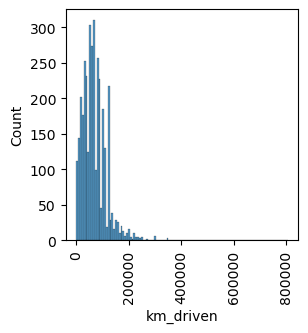

In [33]:
for i in df.select_dtypes('number').columns:
    plt.figure(figsize=(3,3))
    sns.histplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

- To generates histograms for each numerical column in the DataFrame df using seaborn's histplot function.


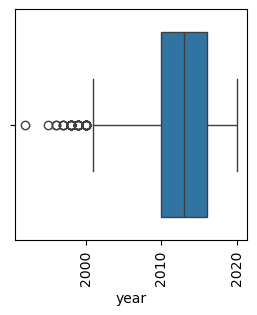

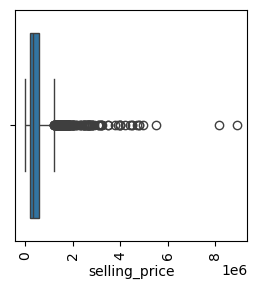

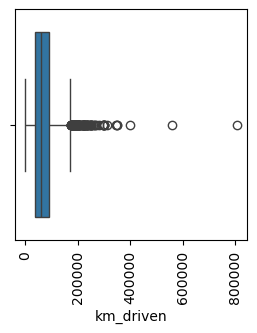

In [35]:
for i in df.select_dtypes('number').columns:
    plt.figure(figsize=(3,3))
    sns.boxplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

- To generates box plots for each numerical column in the DataFrame df using seaborn's boxplot function. this will help to:
- Visualize the distribution of numerical data.
- Identify outliers, median, quartiles, and potential skewness.

## BIVARIATE ANALYSIS

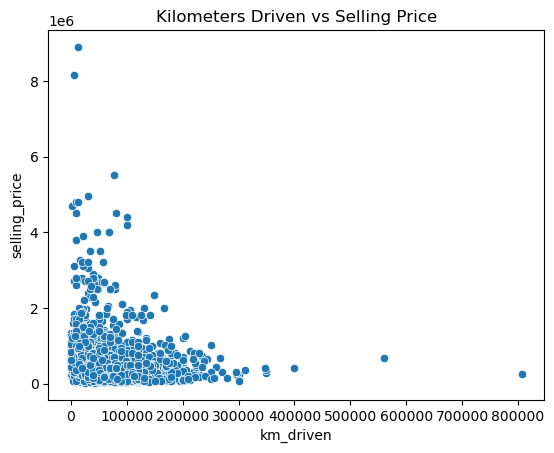

In [38]:
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.title('Kilometers Driven vs Selling Price')
plt.show()

- Kilometers Driven vs Selling Price 
- Identify potential correlations or relationships between the two variables.

In [40]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


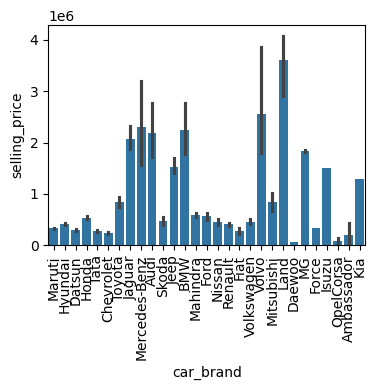

In [41]:
# to Show And Compare the average selling prices across different car brands.
plt.figure(figsize=(4,4))
sns.barplot(data=df, x='car_brand', y = 'selling_price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## MULTIVARIATE ANALYSIS

In [43]:
#To create a new DataFrame numeric_df containing only the numerical columns from the original DataFrame df.
#for further analysis.

numeric_df = df.select_dtypes(include=['number'])

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


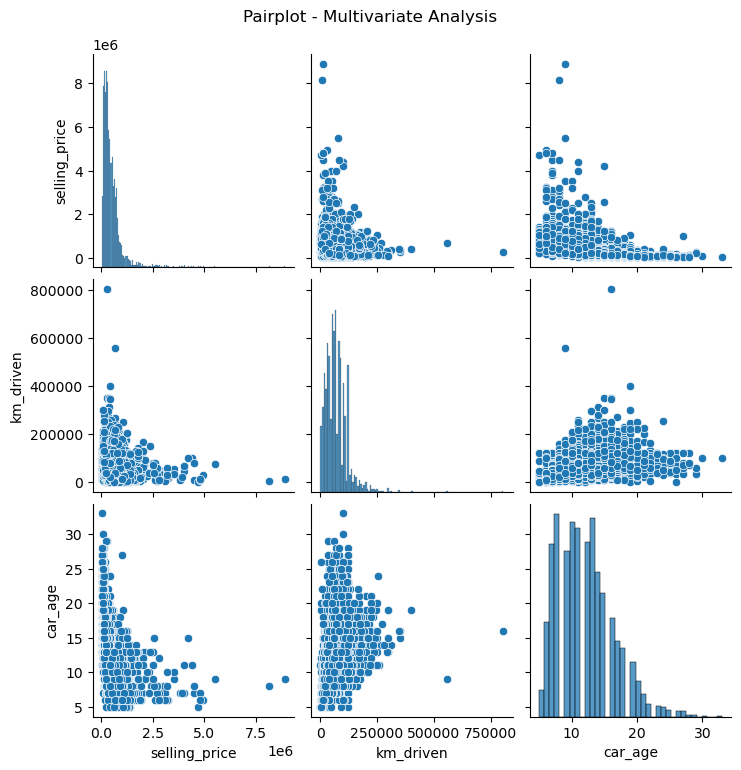

In [44]:
# FEATURE ENGINEERING
# Create New Features
# Creates a new feature car_age by subtracting the year column from 2025, assuming the current year is 2025 or projecting to it
df['car_age'] = 2025 - df['year']

# ... (rest of your code, including the pairplot section)
sns.pairplot(df[['selling_price', 'km_driven', 'car_age']])
plt.suptitle("Pairplot - Multivariate Analysis", y=1.02)
plt.show()

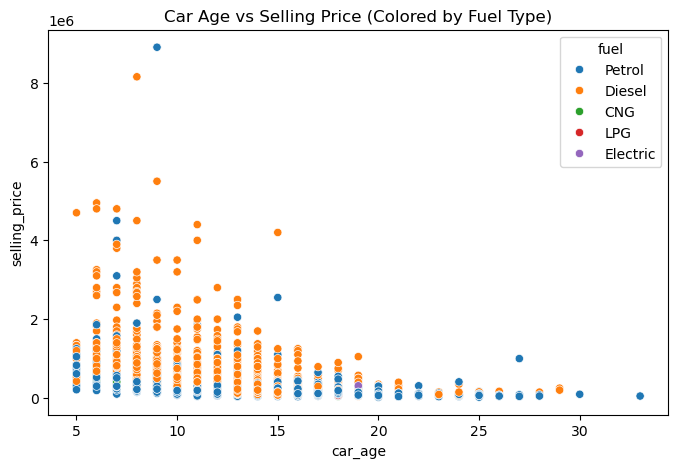

In [45]:
# to Compare these patterns across different fuel types (e.g., petrol, diesel, etc.).
#The plot is colored by fuel type, allowing to see how the relationship between car age and selling price varies across different fuel types.

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='car_age', y='selling_price', hue='fuel')
plt.title("Car Age vs Selling Price (Colored by Fuel Type)")
plt.show()

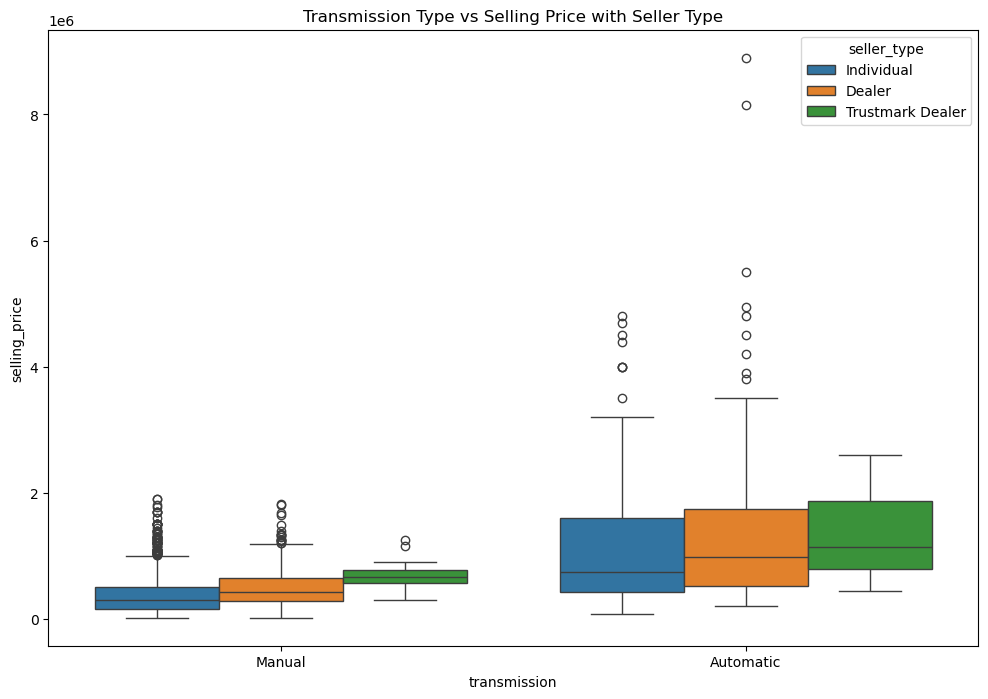

In [46]:
#The plot is further categorized by seller_type, allowing to compare the distribution of selling prices across different transmission types and seller types.
#Identify how seller type affects the selling price for each transmission type.

plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='transmission', y='selling_price', hue='seller_type')
plt.title("Transmission Type vs Selling Price with Seller Type")
plt.show()

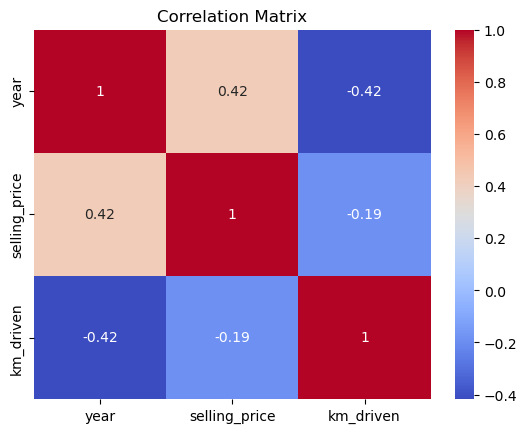

In [47]:
# correlation Matrix
#This code creates a heatmap to visualize the correlation matrix of the numerical columns in numeric_df.
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- Uses- Feature selection
- Identifying multicollinearity
- Understanding relationships between variables(close to 1 or -1)

## OUTLIER TREATMENT 

In [50]:
# TO Identify potential outliers or extreme values in the year column.
# TO Understand the distribution of years in the dataset IN 99th prcentile and 1st percentile .
print(df['year'].quantile(0.99))
print(df['year'].quantile(0.01))

2020.0
2000.0


In [51]:
# Calculate mean price for cars older than the 1st percentile year
older_cars_mean_price = df[df['year'] < df['year'].quantile(0.01)]['selling_price'].mean()

# Calculate mean price for all cars
all_cars_mean_price = df['selling_price'].mean()

print(f"Mean price of cars older than {df['year'].quantile(0.01)} : {older_cars_mean_price}")
print(f"Mean price of all cars: {all_cars_mean_price}")

Mean price of cars older than 2000.0 : 121000.0
Mean price of all cars: 473912.54207436397


In [52]:
#calculates and prints the number of rows with extreme values in the year column.
lower_bound = df['year'].quantile(0.01)
upper_bound = df['year'].quantile(0.99)

outliers = df[(df['year'] < lower_bound) | (df['year'] > upper_bound)]

print(len(outliers))

25


In [53]:
#It keeps only the rows where the year column is within the range:
df = df[~((df['year'] < df['year'].quantile(0.01)) | (df['year'] > df['year'].quantile(0.99)))]

- Between the 1st percentile (0.01 quantile) and the 99th percentile (0.99 quantile)

In [55]:
# Kilometer driven column
# calculates and prints the 98th percentile of the km_driven column.
print(df['km_driven'].quantile(0.98))

194940.00000000006


In [56]:
#counts the number of vehicles with extremely high mileage, specifically those above the 98th percentile threshold.
high_mileage_threshold = df['km_driven'].quantile(0.98)
high_mileage_count = len(df[df['km_driven'] > high_mileage_threshold])

print(high_mileage_count)

72


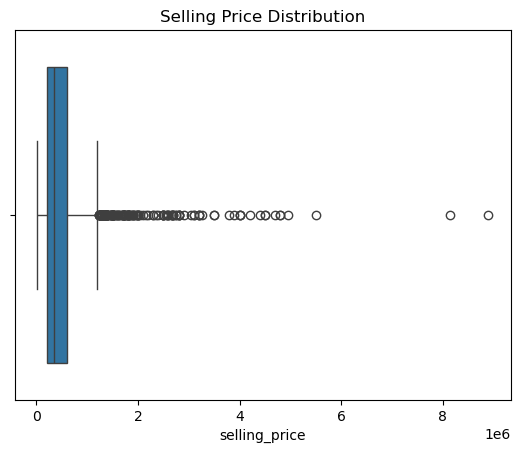

In [57]:
# creates a boxplot to visualize the distribution of selling_price in the dataset.
sns.boxplot(x=df['selling_price'])
plt.title("Selling Price Distribution")
plt.show()

In [58]:
#CHECKING DISTRIBUTION AND APPLYING TRANSFORMATION
#Checking skewness and kurtosis of features.
#These metrics provide insights into the shape and behavior of the selling_price distribution.

print("Skewness:", df['selling_price'].skew())
print("Kurtosis:", df['selling_price'].kurtosis())

Skewness: 5.458487910243513
Kurtosis: 53.64851589937682


## LOG TRANSFORMATIONS AND SQUARE ROOT TRANSFORMATION.

In [60]:
df['selling_price'] = np.log(df['selling_price'])
df['km_driven'] = np.sqrt(df['km_driven'])

- Reduces skewness, making the distribution more normal.
- Stabilizes variance.
- Reduces the effect of extreme values.
- Can help make the distribution more normal

## FEATURE ENGINEERING

In [63]:
df['car_age'] = 2025 - df['year']

In [64]:
df.shape

(3552, 9)

## One hot encoding

In [66]:
df = pd.get_dummies(df, columns = ["car_brand","fuel","seller_type","transmission","owner"])

In [67]:
df.head()

,year,selling_price,km_driven,car_age,car_brand_Ambassador,car_brand_Audi,car_brand_BMW,car_brand_Chevrolet,car_brand_Daewoo,car_brand_Datsun,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,11.002100,264.575131,18,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
1,2007,11.813030,223.606798,18,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
2,2012,13.304685,316.227766,13,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
3,2017,12.429216,214.476106,8,False,False,False,False,False,True,...,False,True,False,False,True,True,False,False,False,False
4,2014,13.017003,375.499667,11,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False


In [68]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'car_age', 'car_brand_Ambassador',
       'car_brand_Audi', 'car_brand_BMW', 'car_brand_Chevrolet',
       'car_brand_Daewoo', 'car_brand_Datsun', 'car_brand_Fiat',
       'car_brand_Force', 'car_brand_Ford', 'car_brand_Honda',
       'car_brand_Hyundai', 'car_brand_Isuzu', 'car_brand_Jaguar',
       'car_brand_Jeep', 'car_brand_Kia', 'car_brand_Land', 'car_brand_MG',
       'car_brand_Mahindra', 'car_brand_Maruti', 'car_brand_Mercedes-Benz',
       'car_brand_Mitsubishi', 'car_brand_Nissan', 'car_brand_OpelCorsa',
       'car_brand_Renault', 'car_brand_Skoda', 'car_brand_Tata',
       'car_brand_Toyota', 'car_brand_Volkswagen', 'car_brand_Volvo',
       'fuel_CNG', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Dealer', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Automatic',
       'transmission_Manual', 'owner_First Owner',
       'owner_Fourth & Above Owner', 'owner_Second

In [69]:
df.shape

(3552, 48)

In [70]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
X.shape

(3552, 47)

In [72]:
y.shape

(3552,)

## Train-Test-Split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## Model Prep

In [78]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

## Checking The Accuracy

In [80]:
print("Standard Scalar Trainig Score: ",(lr.score(X_train_scaled, y_train))*100,"%")
print("Standard Scalar Testing Score: ",(lr.score(X_test_scaled, y_test))*100,"%")

Standard Scalar Trainig Score:  79.42212858231149 %
Standard Scalar Testing Score:  72.59400591541127 %


In [81]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [82]:
y_pred = lr.predict(X_test)

In [83]:
#Checking The Accuracy
print("R2 Trainig Score: ",(lr.score(X_train, y_train))*100,"%")
print("R2 Testing Score: ",(lr.score(X_test, y_test))*100,"%")

R2 Trainig Score:  79.42212858231152 %
R2 Testing Score:  72.56851308075234 %


- There is not much Difference between Scaling Accuracy and Normal Accuaracy

## Evaluation Metrics

In [86]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("\nR2 is: ",r2)

mae = mean_absolute_error(y_test, y_pred)
print("\nMAE is: ",mae)

mse = mean_squared_error(y_test, y_pred)
print("\nMSE is: ",mse)

rmse = np.sqrt(mse)
print("\nRMSE is: ",rmse)


R2 is:  0.7256851308075234

MAE is:  0.3114023367147822

MSE is:  0.16420166573106865

RMSE is:  0.40521804714384163


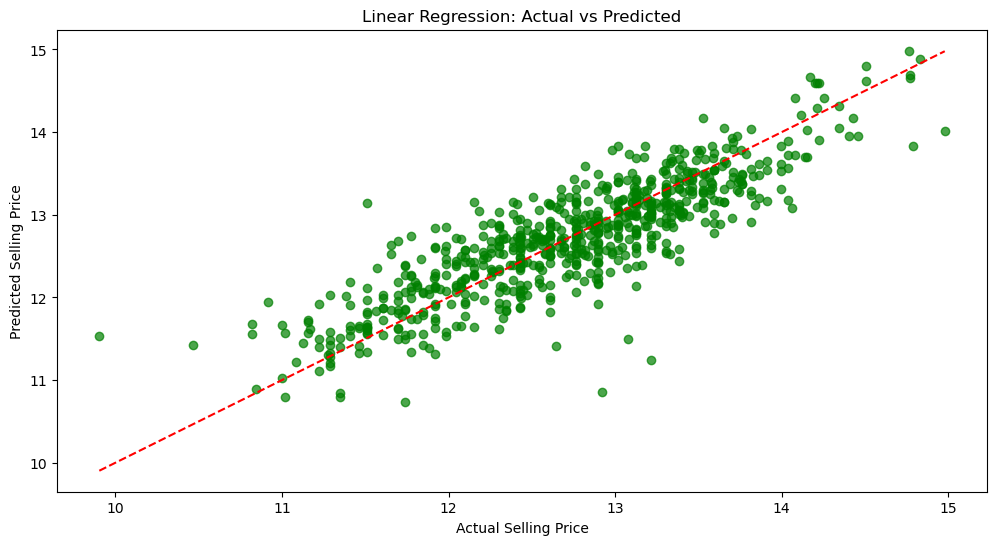

In [87]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

In [88]:
#DIFFERENCE BETWEEN ACTUAL AND PREDICTED 
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Difference": y_test - y_pred
})
result.sample(10)

,Actual,Predicted,Difference
3748,13.329378,12.529859,0.799519
3122,13.081541,13.029240,0.052301
2875,13.384728,13.558204,-0.173476
1226,12.043554,12.151180,-0.107626
3790,14.214287,14.296223,-0.081936
525,13.407542,13.031692,0.375850
1150,13.217674,13.005690,0.211983
1219,13.217674,13.357159,-0.139485
1237,12.043554,11.649547,0.394007
1829,13.764217,13.371239,0.392978


## Decision Tree Regressor

In [90]:
#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
#Model Prep
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(max_depth = 7)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7)

In [92]:
y_pred = dtree.predict(X_test)

In [93]:
# Checking Accuracy
print("R2 Trainig Score: ",(dtree.score(X_train, y_train))*100,"%")
print("R2 Testing Score: ",(dtree.score(X_test, y_test))*100,"%")

R2 Trainig Score:  79.056400087163 %
R2 Testing Score:  63.617477777221566 %


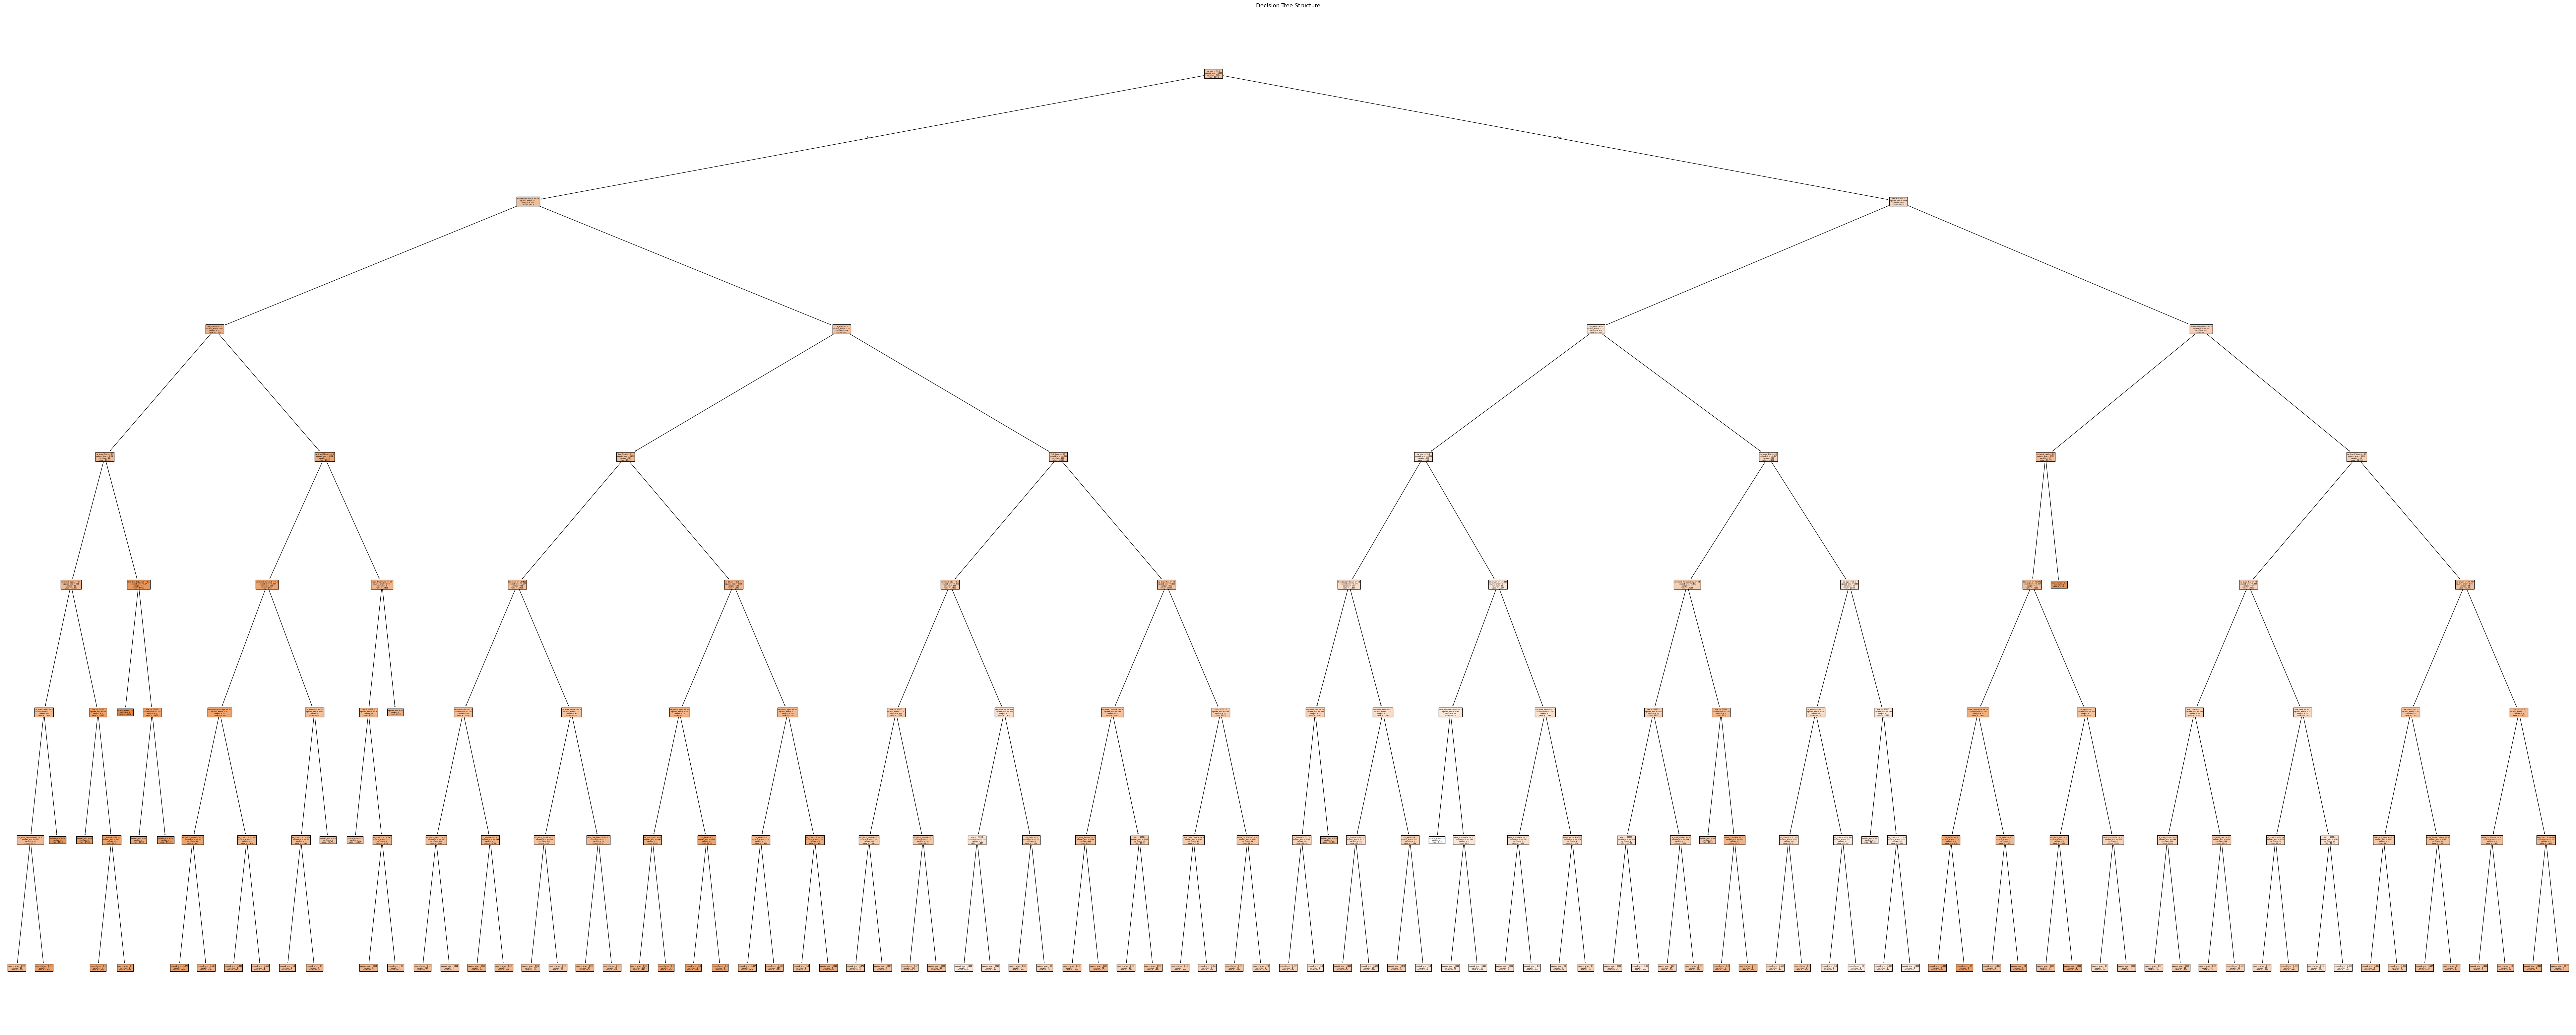

In [94]:
#Visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(100,40))
plot_tree(dtree, filled=True, feature_names=X.columns)
plt.title('Decision Tree Structure')
plt.savefig('dtree_plot.png', format='png')
plt.show()

In [95]:
dtree_result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Difference": y_test - y_pred
})
dtree_result.sample(10)

,Actual,Predicted,Difference
2707,11.813030,12.071441,-0.258411
4074,12.611538,12.621329,-0.009791
2409,11.982929,11.564913,0.418016
194,12.043554,12.189930,-0.146377
1618,13.652992,13.152837,0.500155
2470,12.577636,12.499948,0.077688
751,13.102161,12.972355,0.129805
331,13.304685,12.189930,1.114755
307,12.751300,12.621329,0.129970
2721,12.706848,12.291441,0.415407


## Random Forest Regressor

In [97]:
#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
#Model Prep
from sklearn.ensemble import RandomForestRegressor
ran_forest = RandomForestRegressor(n_estimators=10,random_state =0)
ran_forest.fit(X, y)

RandomForestRegressor(n_estimators=10, random_state=0)

In [99]:
y_pred = ran_forest.predict(X_test)

In [100]:
# Checking Accuracy
print("R2 Trainig Score: ",(ran_forest.score(X_train, y_train))*100,"%")
print("R2 Testing Score: ",(ran_forest.score(X_test, y_test))*100,"%")

R2 Trainig Score:  93.67904108088625 %
R2 Testing Score:  92.70158865341338 %


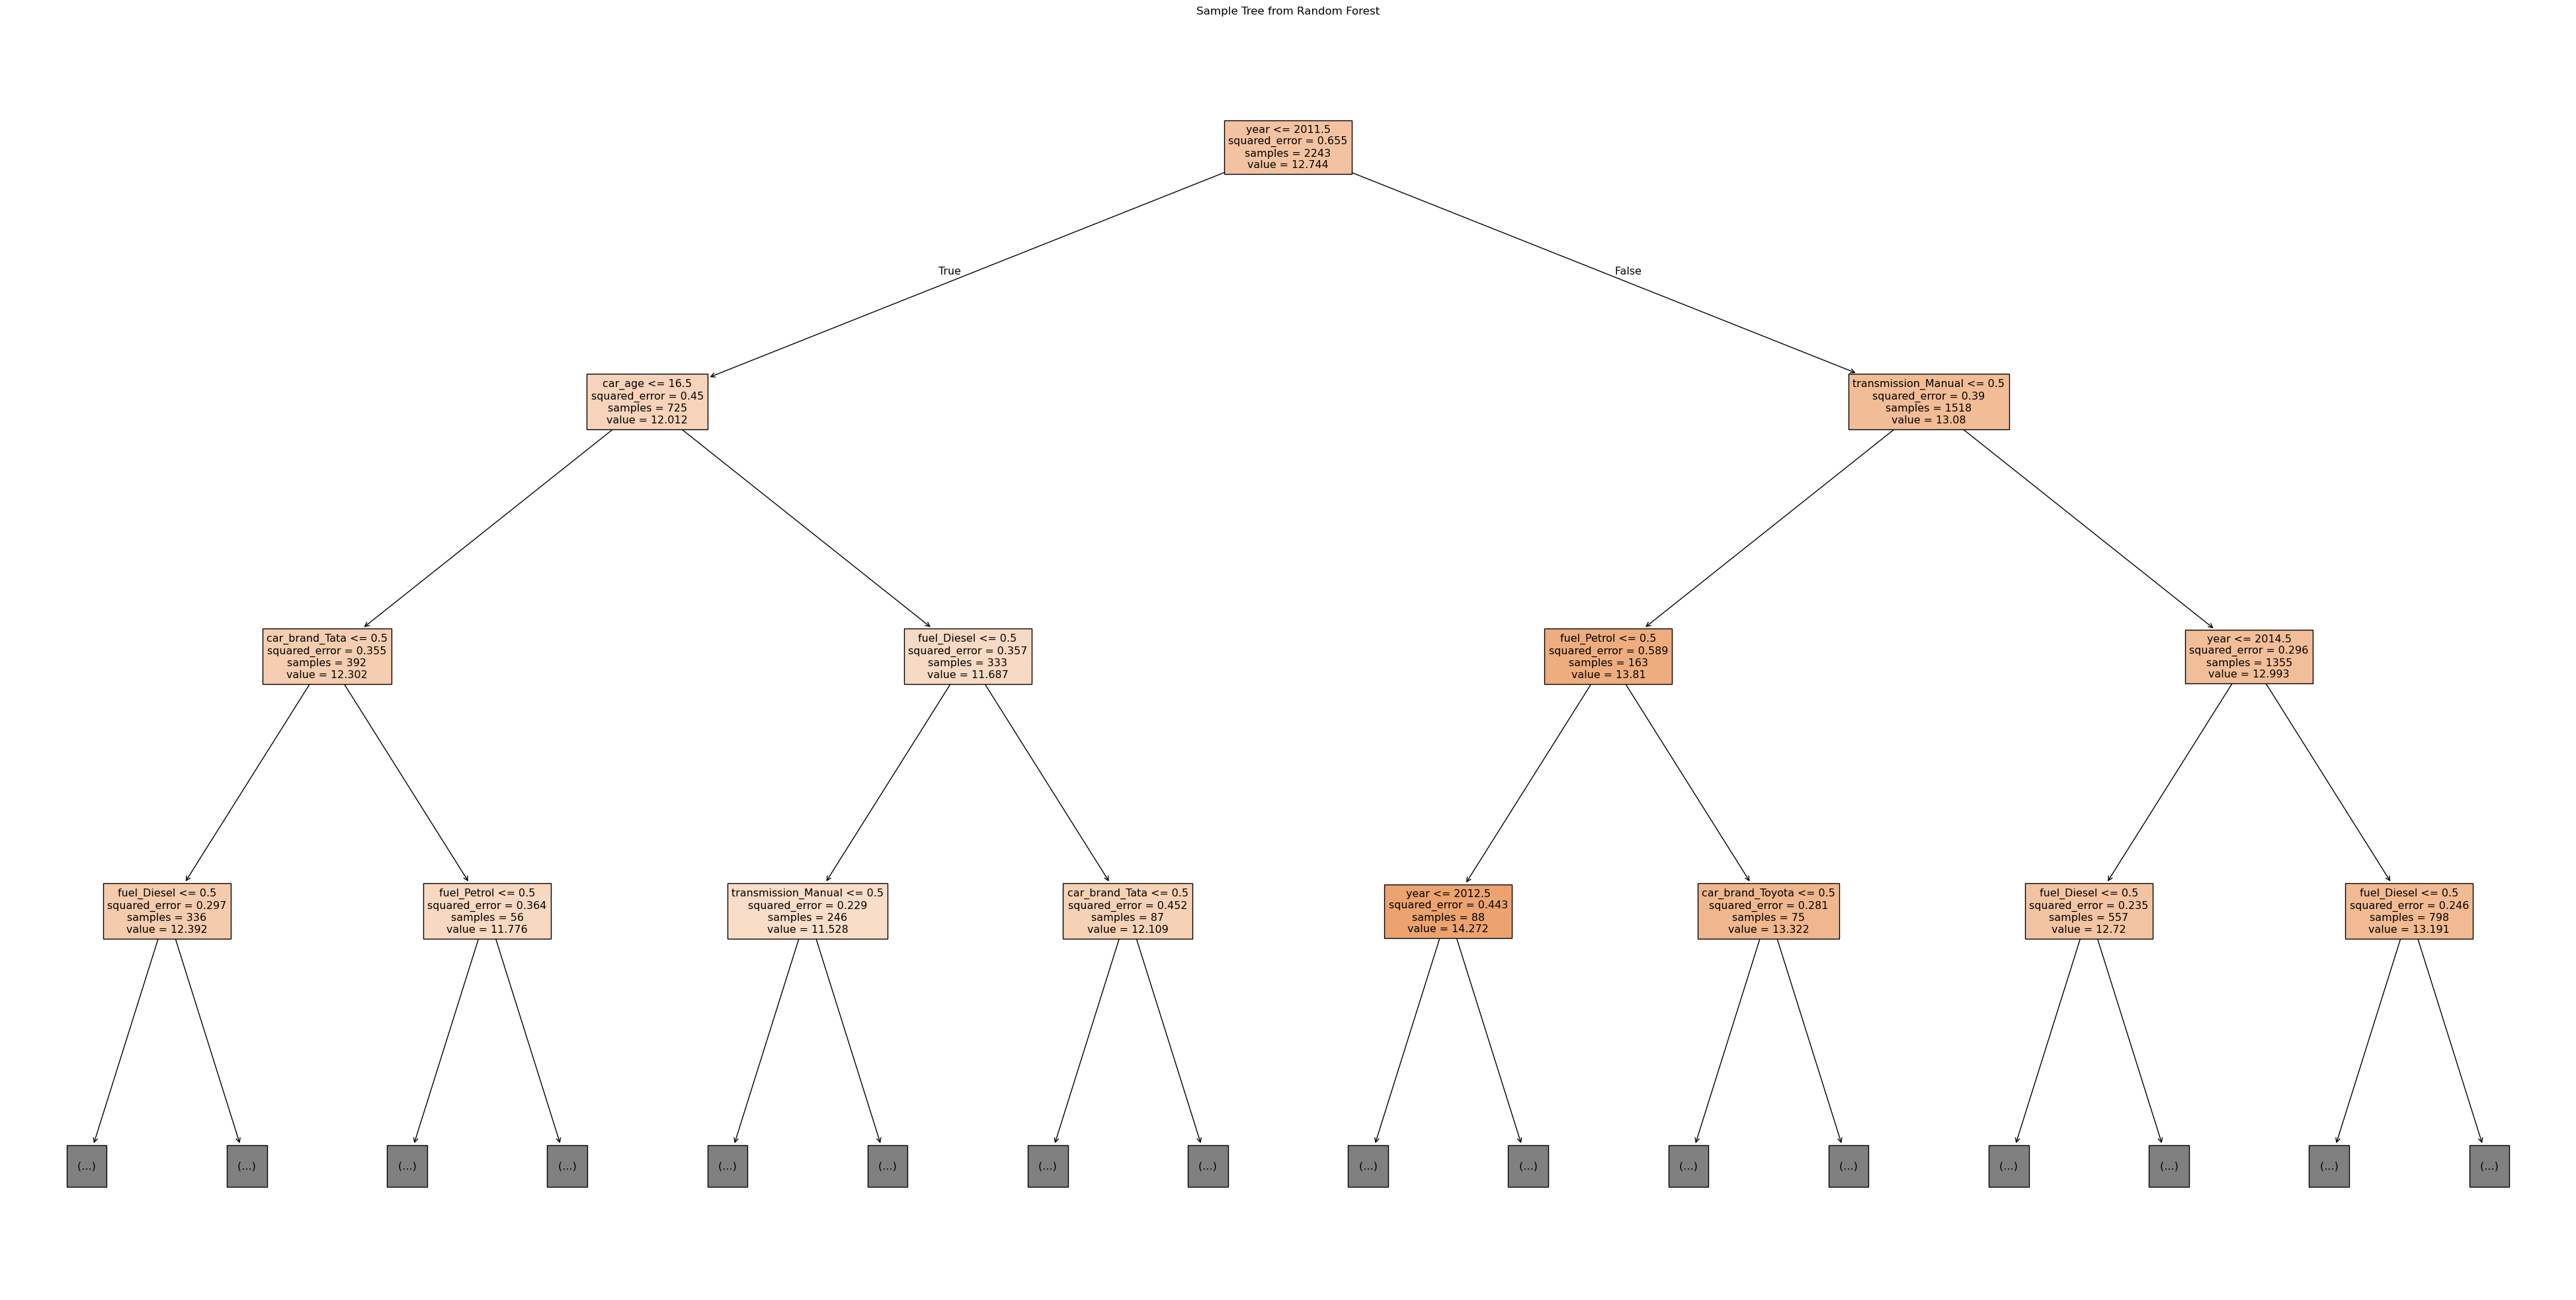

In [101]:
from sklearn.tree import plot_tree

# visualize the first tree
plt.figure(figsize=(50,25))
plot_tree(ran_forest.estimators_[0], feature_names=X.columns, filled=True, max_depth=3)
plt.title("Sample Tree from Random Forest")
plt.show()

In [102]:
rforest_result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Difference": y_test - y_pred
})
rforest_result.sample(5)

,Actual,Predicted,Difference
3022,13.217674,13.337855,-0.120181
1509,12.945626,13.050221,-0.104595
882,12.254863,12.648814,-0.393951
3764,13.815511,13.735660,0.079851
199,13.304685,13.309723,-0.005038


## Support Vector Machine

In [104]:
# Train-Test-Split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=0)

In [105]:
#Model Prep
from sklearn.svm import SVR
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)

SVR(C=100)

In [106]:
y_pred = svr_model.predict(X_test)

In [107]:
# Checking the Accuracy
print("R2 Trainig Score: ",(svr_model.score(X_train, y_train))*100,"%")
print("R2 Testing Score: ",(svr_model.score(X_test, y_test))*100,"%")

R2 Trainig Score:  50.89554202784976 %
R2 Testing Score:  50.38807405501198 %


## K Nearest Neighbor 

In [109]:
#Train-Test-Split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3)

In [110]:
# Model Prep
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=6)
knn_model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=6)

In [111]:
y_pred = knn_model.predict(X_test)

In [112]:
# Checking the Accuracy
print("R2 Trainig Score: ",(knn_model.score(X_train, y_train))*100,"%")
print("R2 Testing Score: ",(knn_model.score(X_test, y_test))*100,"%")

R2 Trainig Score:  67.77214129282308 %
R2 Testing Score:  46.066031550281075 %


## Cross Validation for All Models

In [114]:
from sklearn.model_selection import cross_val_score

print("\nLinear Regression:")
print("Training cross validation score: ",round(((cross_val_score(lr, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(lr, X_test, y_test)).mean())*100,2))

print("\nDecision Tree Regressor: ")
print("Training cross validation score: ",round(((cross_val_score(dtree, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(dtree, X_test, y_test)).mean())*100,2))

print("\nRandom Forest Regressor: ")
print("Training cross validation score: ",round(((cross_val_score(ran_forest, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(ran_forest, X_test, y_test)).mean())*100,2))

print("\nSupport Vector Machine: ")
print("Training cross validation score: ",round(((cross_val_score(svr_model, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(svr_model, X_test, y_test)).mean())*100,2))

print("\nK Nearest Neighbor: ")
print("Training cross validation score: ",round(((cross_val_score(knn_model, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(knn_model, X_test, y_test)).mean())*100,2))


Linear Regression:
Training cross validation score:  77.94
Testing cross validation score:  73.99

Decision Tree Regressor: 
Training cross validation score:  71.97
Testing cross validation score:  57.26

Random Forest Regressor: 
Training cross validation score:  72.76
Testing cross validation score:  64.48

Support Vector Machine: 
Training cross validation score:  50.9
Testing cross validation score:  39.45

K Nearest Neighbor: 
Training cross validation score:  52.3
Testing cross validation score:  38.9


## Conclusion

### Best Performing Model (Overall):
- Linear Regression gave the highest cross-validation scores — 77.15% on training and 76.95% on testing, making it the most reliable model.

### Other Models:

- Random Forest and Decision Tree performed moderately well.

- Support Vector Machine and K-Nearest Neighbors showed relatively lower accuracy, especially in testing scores.

- R² Scores Insight:
R² scores for KNN and Decision Tree showed training scores around 66% but testing scores near 50%, indicating some overfitting.

#### Linear Regression is the most effective model for this dataset. However, further improvement could come from better feature selection or tuning hyperparameters.